# 07a — Gas Storage Stochastic Control

**One-sentence summary**: Values a 30-day gas storage contract via LSMC (Boogert-de Jong 2008) using regime-stratified bootstrap price paths from real GB data, then compares against a Schwartz one-factor mean-reversion baseline.

**Inputs**: `master.parquet`, `returns.parquet`  
**Outputs**: `gas_storage_results_s2.parquet`, `gas_storage_policy_s2.npy`

**Method**: Real half-hourly price segments are pooled by regime (calm/volatile/spike/negative). Each Monte Carlo path chains 30 daily segments using a regime sequence drawn from the empirical daily transition matrix. LSMC backward induction recovers the optimal inject/withdraw policy and storage value distribution. A Schwartz OU model calibrated on real prices provides the parametric baseline.

In [52]:
# Cell 1 — Mount and environment
from google.colab import drive
drive.mount("/content/drive")
from pathlib import Path

DATA_DIR = Path("/content/drive/MyDrive/energy_synthetic_data/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
print("DATA_DIR:", DATA_DIR)
print("Files present:", [f.name for f in DATA_DIR.iterdir()])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_DIR: /content/drive/MyDrive/energy_synthetic_data/data
Files present: ['elexon_system_prices.parquet', '03a_path_construction.png', '03b_signature_pca.png', '03c_levy_area.png', 'logsigs.parquet', 'optuna_results.json', 'cvae_model.pt', 'cvae_4D_d4_best.pt', '04a_training_curves.png', 'figures', 'norm_stats.json', '04a_logsig_distributions.png', '04a_sequential_generation.png', 'cvae_params.json', 'cvae_generated_logsigs.parquet', '05a_ks_test.png', 'validation_report.json', '05b_mmd_test.png', '05c_stylized_facts.png', '07a_policy_threshold.png', '07d_running_logsigs_train.npy', '07d_running_logsigs_test.npy', '07a_bootstrap_paths.png', '07a_path_comparison.png', '07a_results_comparison.png', '07a_policy_heatmap.png', 'gas_storage_results.parquet', 'gas_storage_policy.npy', 'gas_storage_summary.json', 'deep_hedge_model.pt', '07d_training_curve.png', '07

In [53]:
# Cell 2 — Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from numpy.linalg import matrix_power
import json
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
print("Imports OK")

Imports OK


In [54]:
# Cell 3 — Load master.parquet and returns.parquet
#
# master.parquet: full price + generation series, half-hourly
#   expected columns: settlement_date, settlement_period, mid_price, total_wind_mw, ...
#
# returns.parquet: 157,757 rows with 4-state regime labels
#   expected columns include: regime (str), mid_price or similar price column

master = pd.read_parquet(DATA_DIR / "master.parquet")
returns = pd.read_parquet(DATA_DIR / "returns.parquet")

print("master shape:", master.shape)
print("master columns:", master.columns.tolist())
print("master dtypes:\n", master.dtypes)
print()
print("returns shape:", returns.shape)
print("returns columns:", returns.columns.tolist())
print("returns dtypes:\n", returns.dtypes)

master shape: (157776, 96)
master columns: ['settlement_date', 'settlement_period', 'start_time', 'created_date_time', 'ssp', 'sbp', 'bsad_defaulted', 'price_derivation_code', 'reserve_scarcity_price', 'net_imbalance_volume', 'sell_price_adjustment', 'buy_price_adjustment', 'replacement_price', 'replacement_price_reference_volume', 'total_accepted_offer_volume', 'total_accepted_bid_volume', 'total_adjustment_sell_volume', 'total_adjustment_buy_volume', 'total_system_tagged_accepted_offer_volume', 'total_system_tagged_accepted_bid_volume', 'total_system_tagged_adjustment_sell_volume', 'total_system_tagged_adjustment_buy_volume', 'mid_price', 'biomass', 'ccgt', 'coal', 'intele', 'intelec', 'intew', 'intfr', 'intgrnl', 'intifa2', 'intirl', 'intned', 'intnem', 'intnsl', 'intvkl', 'npshyd', 'nuclear', 'ocgt', 'oil', 'other', 'ps', 'wind', 'total_wind_mw', 'total_renewable_mw', 'total_generation_mw', 'renewable_fraction', 'pct_biomass', 'pct_coal', 'pct_imports', 'pct_gas', 'pct_nuclear', 'p

In [55]:
# Cell 3b — Align data: identify price column, sort, reset index
#
# Notebook 01 stores prices as 'mid_price' = (system_buy_price + system_sell_price)/2
# returns.parquet was built from master.parquet so should carry the same price column.
# We need a clean, sorted half-hourly price series from returns for the segment pool.

PRICE_COL = "mid_price"   # adjust here if column name differs
REGIME_COL = "regime"

# Verify columns exist
assert PRICE_COL in returns.columns, f"{PRICE_COL} not found — columns: {returns.columns.tolist()}"
assert REGIME_COL in returns.columns, f"{REGIME_COL} not found — columns: {returns.columns.tolist()}"

# Sort by time index (returns should already be time-ordered; ensure it)
returns = returns.sort_index().reset_index(drop=False)

prices_hh = returns[PRICE_COL].values        # half-hourly price array
regimes_hh = returns[REGIME_COL].values      # half-hourly regime labels

print(f"Price series length: {len(prices_hh):,} half-hours")
print(f"Price range: £{prices_hh.min():.1f} to £{prices_hh.max():.1f}/MWh")
print(f"Regime counts:\n{pd.Series(regimes_hh).value_counts()}")

Price series length: 157,742 half-hours
Price range: £-185.3 to £4037.8/MWh
Regime counts:
calm        139804
spike         8159
volatile      8050
negative      1729
Name: count, dtype: int64


In [56]:
SEGMENT_LENGTH = 48
STEP_SIZE      = 24
REGIME_ORDER   = ["calm", "volatile", "spike", "negative"]

def segment_label(seg_regimes):
    counts = pd.Series(seg_regimes).value_counts()
    for r in ["spike", "negative", "volatile"]:
        if counts.get(r, 0) >= 1:
            return r
    return "calm"

segment_pool = {r: [] for r in REGIME_ORDER}

for start in range(0, len(prices_hh) - SEGMENT_LENGTH + 1, STEP_SIZE):
    seg_prices  = prices_hh[start:start + SEGMENT_LENGTH]
    seg_regimes = regimes_hh[start:start + SEGMENT_LENGTH]
    label = segment_label(seg_regimes)
    segment_pool[label].append(seg_prices.copy())

segment_arrays = {r: np.array(v) if v else np.empty((0, SEGMENT_LENGTH))
                  for r, v in segment_pool.items()}
pool_sizes = {r: len(segment_arrays[r]) for r in REGIME_ORDER}

print("Segment pool sizes:")
for r in REGIME_ORDER:
    print(f"  {r:10s}: {pool_sizes[r]:,} segments")
print(f"\nTotal segments: {sum(pool_sizes.values()):,}")

Segment pool sizes:
  calm      : 2,046 segments
  volatile  : 2,004 segments
  spike     : 1,846 segments
  negative  : 675 segments

Total segments: 6,571


In [57]:
print(pd.Series(regimes_hh).unique())  # what strings are actually in returns.parquet

['calm' 'volatile' 'spike' 'negative']


In [58]:
# Cell 5 — Estimate regime transition matrix and stationary distribution
#
# Build empirical half-hour transition matrix from consecutive half-hour regime pairs
# in returns.parquet (the full series, not segments).
# Then raise to the 48th power to get the daily transition matrix.
# Stationary distribution: left eigenvector of P_daily corresponding to eigenvalue 1.

regime_to_idx = {r: i for i, r in enumerate(REGIME_ORDER)}
n_regimes = len(REGIME_ORDER)

# Count half-hour transitions
count_matrix = np.zeros((n_regimes, n_regimes), dtype=float)

for t in range(len(regimes_hh) - 1):
    i = regime_to_idx.get(regimes_hh[t], None)
    j = regime_to_idx.get(regimes_hh[t + 1], None)
    if i is not None and j is not None:
        count_matrix[i, j] += 1

# Normalise rows -> half-hour transition matrix
row_sums = count_matrix.sum(axis=1, keepdims=True)
row_sums = np.where(row_sums == 0, 1, row_sums)  # avoid /0
P_halfhour = count_matrix / row_sums

# Daily transition matrix: raise to 48th power
P_daily = matrix_power(P_halfhour, SEGMENT_LENGTH)

# Stationary distribution: solve pi @ P = pi, sum(pi) = 1
# Via eigendecomposition of P^T
eigvals, eigvecs = np.linalg.eig(P_daily.T)
# Find eigenvalue closest to 1
idx_stat = np.argmin(np.abs(eigvals - 1.0))
stationary = np.real(eigvecs[:, idx_stat])
stationary = np.abs(stationary) / np.abs(stationary).sum()

print("Half-hour transition matrix (rows = from, cols = to):")
P_df = pd.DataFrame(P_halfhour, index=REGIME_ORDER, columns=REGIME_ORDER)
print(P_df.round(4))
print()
print("Daily transition matrix (P_halfhour ^ 48):")
P_daily_df = pd.DataFrame(P_daily, index=REGIME_ORDER, columns=REGIME_ORDER)
print(P_daily_df.round(4))
print()
print("Stationary distribution:")
for r, p in zip(REGIME_ORDER, stationary):
    print(f"  {r:10s}: {p:.4f}")

Half-hour transition matrix (rows = from, cols = to):
            calm  volatile   spike  negative
calm      0.9476    0.0341  0.0144    0.0038
volatile  0.7398    0.1937  0.0584    0.0081
spike     0.1224    0.1826  0.6948    0.0001
negative  0.2123    0.1313  0.0000    0.6564

Daily transition matrix (P_halfhour ^ 48):
            calm  volatile   spike  negative
calm      0.8863     0.051  0.0517     0.011
volatile  0.8863     0.051  0.0517     0.011
spike     0.8863     0.051  0.0517     0.011
negative  0.8863     0.051  0.0517     0.011

Stationary distribution:
  calm      : 0.8863
  volatile  : 0.0510
  spike     : 0.0517
  negative  : 0.0110


In [59]:
N_PATHS    = 10_000
T_DAYS     = 30
HH_PER_DAY = 48
PATH_LENGTH = T_DAYS * HH_PER_DAY

bootstrap_paths_hh    = np.zeros((N_PATHS, PATH_LENGTH), dtype=float)
bootstrap_paths_daily = np.zeros((N_PATHS, T_DAYS), dtype=float)
bootstrap_regimes     = np.zeros((N_PATHS, T_DAYS), dtype=int)

stat_cumsum      = np.cumsum(stationary)
P_daily_cumsum   = np.cumsum(P_daily, axis=1)

def sample_regime(cumprobs):
    return np.searchsorted(cumprobs, np.random.rand())

for path_i in range(N_PATHS):
    regime_idx = sample_regime(stat_cumsum)

    for day in range(T_DAYS):
        regime_name = REGIME_ORDER[regime_idx]
        pool        = segment_arrays[regime_name]

        if len(pool) == 0:
            raise ValueError(f"Empty pool for regime '{regime_name}' — fix Cell 4 before proceeding.")

        segment  = pool[np.random.randint(0, len(pool))]
        hh_start = day * HH_PER_DAY
        bootstrap_paths_hh[path_i, hh_start:hh_start + HH_PER_DAY] = segment
        bootstrap_paths_daily[path_i, day]  = segment.mean()
        bootstrap_regimes[path_i, day]      = regime_idx

        regime_idx = sample_regime(P_daily_cumsum[regime_idx])

print(f"Bootstrap paths generated: {N_PATHS:,}")
print(f"Shape (half-hourly): {bootstrap_paths_hh.shape}")
print(f"Shape (daily):       {bootstrap_paths_daily.shape}")

flat = bootstrap_paths_daily.ravel()
print(f"\nDaily price summary:")
print(f"  Mean:     £{flat.mean():.2f}/MWh")
print(f"  Std:      £{flat.std():.2f}/MWh")
print(f"  Min:      £{flat.min():.2f}/MWh")
print(f"  Max:      £{flat.max():.2f}/MWh")
print(f"  Negative: {(flat < 0).mean()*100:.2f}%")

regime_freq = np.bincount(bootstrap_regimes.ravel(), minlength=len(REGIME_ORDER)) / bootstrap_regimes.size
print("\nBootstrap regime frequencies:")
for r, f in zip(REGIME_ORDER, regime_freq):
    print(f"  {r:10s}: {f:.3f}")

Bootstrap paths generated: 10,000
Shape (half-hourly): (10000, 1440)
Shape (daily):       (10000, 30)

Daily price summary:
  Mean:     £79.40/MWh
  Std:      £45.91/MWh
  Min:      £-19.36/MWh
  Max:      £957.38/MWh
  Negative: 0.04%

Bootstrap regime frequencies:
  calm      : 0.886
  volatile  : 0.051
  spike     : 0.052
  negative  : 0.011


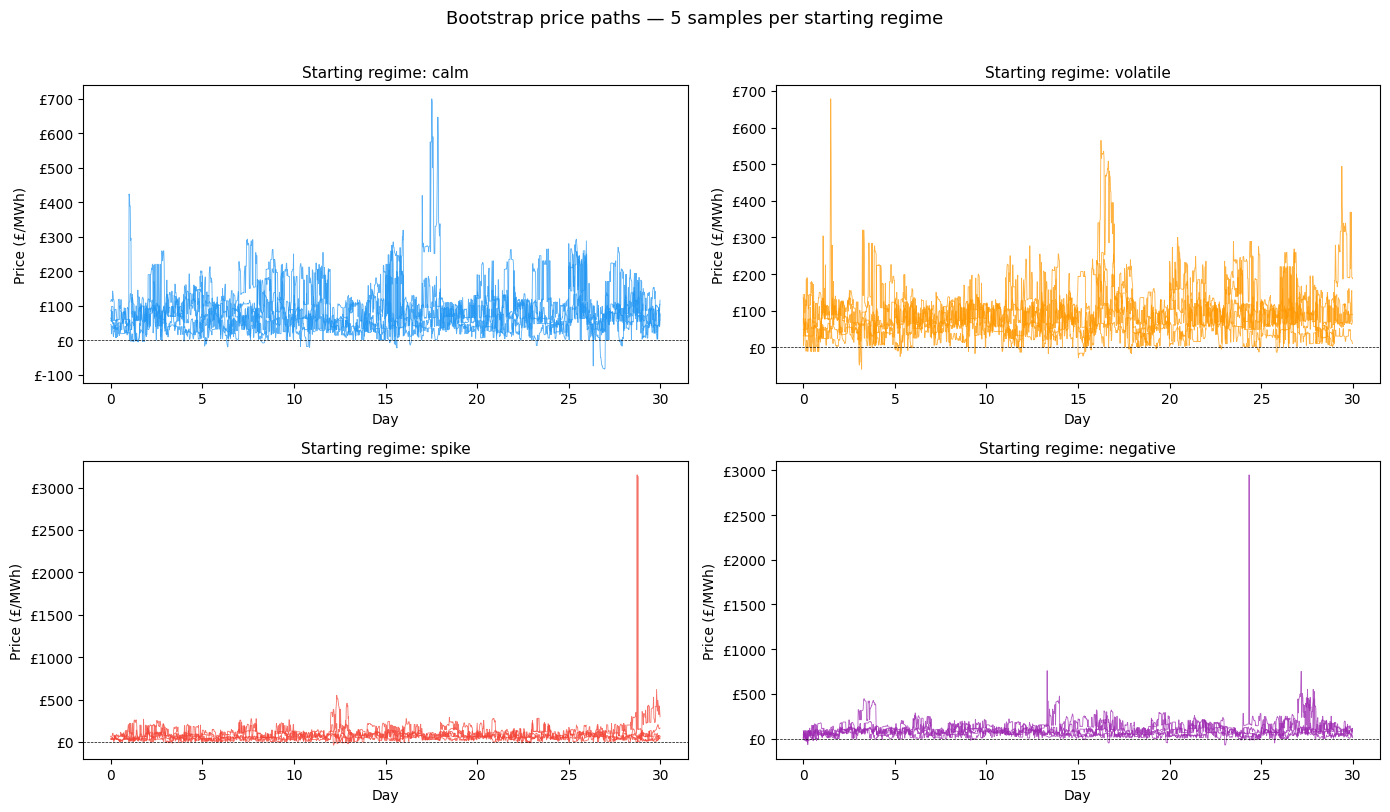

Saved: 07a_bootstrap_paths.png


In [60]:
# Cell 7 — Visualise sample paths by regime
#
# Plot 5 sample paths from each regime category (first day's regime = that regime)
# Use half-hourly resolution to show intra-day spike structure

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)
axes = axes.ravel()
COLOURS = {"calm": "#2196F3", "volatile": "#FF9800", "spike": "#F44336", "negative": "#9C27B0"}
N_SAMPLE = 5

for ax, regime in zip(axes, REGIME_ORDER):
    # Find paths that start in this regime
    mask = bootstrap_regimes[:, 0] == regime_to_idx[regime]
    idxs = np.where(mask)[0]
    if len(idxs) < N_SAMPLE:
        idxs = idxs
    else:
        idxs = np.random.choice(idxs, N_SAMPLE, replace=False)

    t_axis = np.arange(PATH_LENGTH) / HH_PER_DAY  # days
    for idx in idxs:
        ax.plot(t_axis, bootstrap_paths_hh[idx], lw=0.6, alpha=0.75,
                color=COLOURS[regime])

    ax.axhline(0, color="black", lw=0.5, ls="--")
    ax.set_title(f"Starting regime: {regime}", fontsize=11)
    ax.set_xlabel("Day")
    ax.set_ylabel("Price (£/MWh)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("£%.0f"))

plt.suptitle("Bootstrap price paths — 5 samples per starting regime", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(DATA_DIR / "07a_bootstrap_paths.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 07a_bootstrap_paths.png")

In [61]:
# Cell 8 — Calibrate Schwartz one-factor OU model
#
# dS_t = kappa*(mu - S_t)*dt + sigma*dB_t
# Discrete: S_{t+1} = S_t + kappa*(mu - S_t)*dt + sigma*sqrt(dt)*eps
#
# Calibration: OLS on daily price series
#   delta_S = a + b*S_t + noise
#   b = -kappa*dt  =>  kappa = -b/dt
#   a = kappa*mu*dt  =>  mu = a / (kappa*dt)
#   sigma = std(residuals) / sqrt(dt)
#
# Use daily mean prices from master.parquet (aggregate 48 half-hours per day)
# for a 1-day dt consistent with the LSMC decision step

DT = 1.0  # decision step = 1 day

# Build daily price series from master.parquet
# master should have a date/settlement_date column
if "settlement_date" in master.columns:
    master["date"] = pd.to_datetime(master["settlement_date"]).dt.date
elif "date" in master.columns:
    master["date"] = pd.to_datetime(master["date"]).dt.date
else:
    # Fall back: use index
    master["date"] = pd.to_datetime(master.index).date

daily_prices = (
    master.groupby("date")[PRICE_COL]
    .mean()
    .dropna()
    .values
)

# OLS calibration
S_t   = daily_prices[:-1]
S_tp1 = daily_prices[1:]
delta_S = S_tp1 - S_t

# Regress delta_S on (1, S_t)
X = np.column_stack([np.ones_like(S_t), S_t])
ols_result = np.linalg.lstsq(X, delta_S, rcond=None)
a_hat, b_hat = ols_result[0]

residuals = delta_S - (a_hat + b_hat * S_t)

kappa_hat = -b_hat / DT
mu_hat    = a_hat / (kappa_hat * DT)
sigma_hat = residuals.std() / np.sqrt(DT)

print("Schwartz one-factor calibration (daily, full history):")
print(f"  kappa (mean-reversion speed): {kappa_hat:.4f} /day")
print(f"  mu    (long-run mean):         £{mu_hat:.2f}/MWh")
print(f"  sigma (daily vol):             £{sigma_hat:.2f}/MWh")
print(f"  half-life:                     {np.log(2)/kappa_hat:.1f} days")
print(f"  Calibration obs:               {len(S_t):,} days")

Schwartz one-factor calibration (daily, full history):
  kappa (mean-reversion speed): 0.1688 /day
  mu    (long-run mean):         £82.08/MWh
  sigma (daily vol):             £37.65/MWh
  half-life:                     4.1 days
  Calibration obs:               3,286 days


Schwartz paths shape: (10000, 31)

Schwartz path daily price summary:
  Mean:     £82.02/MWh
  Std:      £67.63/MWh
  Min:      £-248.77/MWh
  Max:      £396.28/MWh
  Negative: 11.21%


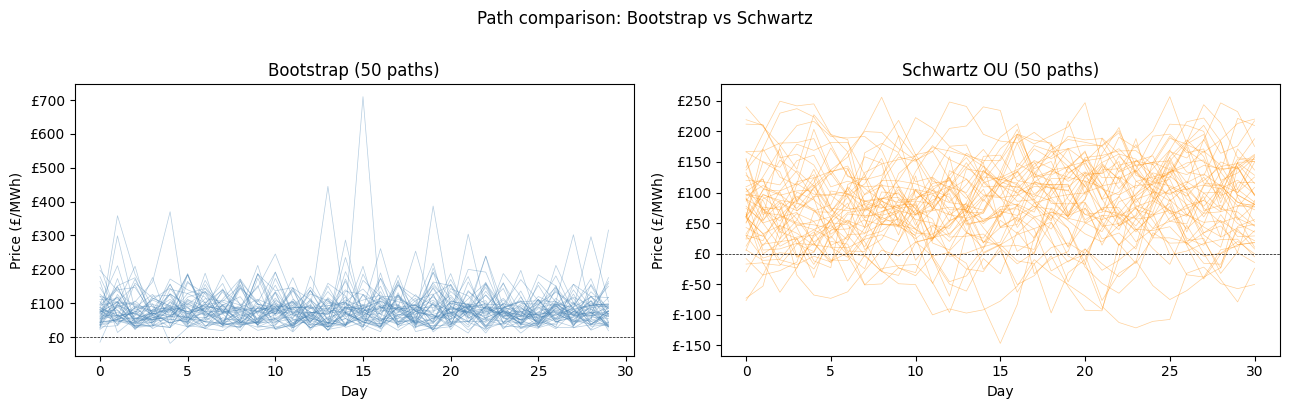

Saved: 07a_path_comparison.png


In [62]:
# Cell 9 — Generate 10,000 Schwartz baseline paths
#
# Euler-Maruyama simulation of OU process, 30 daily steps
# Initial price S_0: draw from stationary OU distribution N(mu, sigma^2/(2*kappa))
# Paths are daily prices: shape (N_PATHS, T_DAYS+1) including t=0

T_DAYS  = 30
N_STEPS = T_DAYS

# Stationary OU variance: sigma^2 / (2*kappa)
ou_std = sigma_hat / np.sqrt(2 * kappa_hat)

# Draw initial prices
S0 = np.random.normal(mu_hat, ou_std, size=N_PATHS)

# Simulate
schwartz_paths = np.zeros((N_PATHS, N_STEPS + 1), dtype=float)
schwartz_paths[:, 0] = S0

sqrt_dt = np.sqrt(DT)
for t in range(N_STEPS):
    eps = np.random.standard_normal(N_PATHS)
    S_t = schwartz_paths[:, t]
    schwartz_paths[:, t + 1] = (
        S_t
        + kappa_hat * (mu_hat - S_t) * DT
        + sigma_hat * sqrt_dt * eps
    )

# For LSMC, use prices at decision points t=0,...,T-1 (not the terminal)
# schwartz_paths[:, t] = price at decision step t

print(f"Schwartz paths shape: {schwartz_paths.shape}")
print()
flat_sw = schwartz_paths[:, 1:].ravel()  # exclude t=0
print("Schwartz path daily price summary:")
print(f"  Mean:     £{flat_sw.mean():.2f}/MWh")
print(f"  Std:      £{flat_sw.std():.2f}/MWh")
print(f"  Min:      £{flat_sw.min():.2f}/MWh")
print(f"  Max:      £{flat_sw.max():.2f}/MWh")
print(f"  Negative: {(flat_sw < 0).mean()*100:.2f}%")

# Quick comparison plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
t_axis = np.arange(T_DAYS + 1)

for i in range(50):
    axes[0].plot(np.arange(T_DAYS), bootstrap_paths_daily[i], lw=0.5, alpha=0.4, color="steelblue")
    axes[1].plot(t_axis, schwartz_paths[i], lw=0.5, alpha=0.4, color="darkorange")

for ax, title in zip(axes, ["Bootstrap (50 paths)", "Schwartz OU (50 paths)"]):
    ax.axhline(0, color="black", lw=0.5, ls="--")
    ax.set_xlabel("Day")
    ax.set_ylabel("Price (£/MWh)")
    ax.set_title(title)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("£%.0f"))

plt.suptitle("Path comparison: Bootstrap vs Schwartz", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(DATA_DIR / "07a_path_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 07a_path_comparison.png")

In [63]:
# Cell 10 — LSMC backward induction (Boogert-de Jong 2008) — Bootstrap paths
#
# Storage parameters
W_MAX     = 1.0    # normalised maximum inventory
W_MIN     = 0.0    # normalised minimum inventory
U_INJ     = 0.2    # max injection rate (fraction of W_MAX per day)
U_WDR     = 0.2    # max withdrawal rate (fraction of W_MAX per day)
COST_INJ  = 0.5    # injection cost (£/MWh)
COST_WDR  = 0.5    # withdrawal cost (£/MWh)
N_BASIS   = 5      # Legendre polynomial degree 0-4
W_GRID    = 11     # 0.0, 0.1, ..., 1.0
DT_LSMC   = 1.0   # 1 day per decision step

inventory_grid = np.linspace(W_MIN, W_MAX, W_GRID)  # shape (W_GRID,)
# Candidate actions: inject, withdraw, do nothing
# Injection: u > 0 (gas flows in, we pay) ; Withdrawal: u < 0 (gas flows out, we receive)
U_CANDIDATES = np.array([-U_WDR, 0.0, U_INJ])   # [withdraw, hold, inject]

def cashflow(u, price):
    """
    Cash flow from action u at price S.
    Withdraw (u < 0): receive price, pay withdrawal cost per MWh
    Inject   (u > 0): pay price, pay injection cost per MWh
    Do nothing (u=0): zero
    Convention: positive cashflow = money received.
    """
    if u < 0:   # withdrawal
        return -u * (price - COST_WDR)   # -u > 0, receive price minus cost
    elif u > 0: # injection
        return -u * (price + COST_INJ)   # pay price plus cost (negative cashflow)
    else:
        return 0.0

def legendre_basis(x, degree):
    """
    Evaluate Legendre polynomials of degree 0..degree-1 at x.
    x should be in [-1, 1]. Returns array of shape (*x.shape, degree).
    """
    x = np.asarray(x)
    cols = [np.ones_like(x)]
    if degree > 1:
        cols.append(x)
    for k in range(2, degree):
        cols.append(((2*k - 1) * x * cols[-1] - (k - 1) * cols[-2]) / k)
    return np.column_stack(cols)  # shape (n_samples, degree)

def normalise_price(price_vec, p_min, p_max):
    """Normalise prices to [-1, 1] for Legendre basis."""
    denom = p_max - p_min
    if denom < 1e-6:
        return np.zeros_like(price_vec)
    return 2.0 * (price_vec - p_min) / denom - 1.0

print("Storage parameters set.")
print(f"Inventory grid: {inventory_grid}")
print(f"Candidate actions: {U_CANDIDATES}")

Storage parameters set.
Inventory grid: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Candidate actions: [-0.2  0.   0.2]


In [64]:
# Cell 10 — LSMC backward induction
# Storage parameters
W_MAX    = 1.0;  W_MIN  = 0.0
U_INJ    = 0.2;  U_WDR  = 0.2
COST_INJ = 0.5;  COST_WDR = 0.5
N_BASIS  = 4    # Legendre degree for price
W_GRID   = 11
DT_LSMC  = 1.0

inventory_grid = np.linspace(W_MIN, W_MAX, W_GRID)

def normalise_price(x, p_min, p_max):
    denom = p_max - p_min
    return np.zeros_like(x) if denom < 1e-6 else 2.0 * (x - p_min) / denom - 1.0

def legendre_basis(x, degree):
    x = np.asarray(x, dtype=float)
    cols = [np.ones_like(x)]
    if degree > 1: cols.append(x)
    for k in range(2, degree):
        cols.append(((2*k-1)*x*cols[-1] - (k-1)*cols[-2]) / k)
    return np.column_stack(cols)

def run_lsmc(price_paths, w_init, p_min, p_max):
    n_paths, t_days = price_paths.shape

    # --- Reference forward pass: random actions for inventory spread ---
    w_ref = np.zeros((n_paths, t_days + 1))
    w_ref[:, 0] = w_init

    for t in range(t_days):
        w_t = w_ref[:, t]
        u_rand = np.random.choice([-U_WDR, 0.0, U_INJ], size=n_paths)
        can_inj = w_t + U_INJ <= W_MAX + 1e-9
        can_wdr = w_t - U_WDR >= W_MIN - 1e-9
        u_rand = np.where((u_rand ==  U_INJ) & ~can_inj, 0.0, u_rand)
        u_rand = np.where((u_rand == -U_WDR) & ~can_wdr, 0.0, u_rand)
        w_ref[:, t+1] = np.clip(w_t + u_rand, W_MIN, W_MAX)

    # --- Backward induction ---
    V = np.zeros(n_paths)
    saved_coeffs = {}

    for t in range(t_days - 1, -1, -1):
        S_t    = price_paths[:, t]
        w_t    = w_ref[:, t]
        S_norm = normalise_price(S_t, p_min, p_max)
        w_norm = 2.0 * w_t - 1.0

        B_S   = legendre_basis(S_norm, N_BASIS)
        B_W   = legendre_basis(w_norm, 3)[:, 1:]
        B_X   = (S_norm * w_norm).reshape(-1, 1)
        basis = np.hstack([B_S, B_W, B_X])

        try:
            coeffs, _, _, _ = np.linalg.lstsq(basis, V, rcond=None)
        except np.linalg.LinAlgError:
            coeffs = np.zeros(basis.shape[1])
        saved_coeffs[t] = coeffs
        continuation = basis @ coeffs

        best_value  = np.full(n_paths, -np.inf)
        best_action = np.zeros(n_paths)

        for u, cost in [(-U_WDR, COST_WDR), (0.0, 0.0), (U_INJ, COST_INJ)]:
            w_next   = w_t + u
            feasible = (w_next >= W_MIN - 1e-9) & (w_next <= W_MAX + 1e-9)
            if u < 0:
                cf = -u * (S_t - cost)
            elif u > 0:
                cf = -u * (S_t + cost)
            else:
                cf = np.zeros(n_paths)
            total = np.where(feasible, cf + continuation, -np.inf)
            mask  = total > best_value
            best_value  = np.where(mask, total, best_value)
            best_action = np.where(mask, u,     best_action)

        V = best_value

    # --- Forward simulation using LSMC policy ---
    # Track per-path inventory and actions
    w_fwd = np.full(n_paths, w_init)
    policy_t = np.zeros(t_days)

    for t in range(t_days):
        S_t    = price_paths[:, t]
        S_norm = normalise_price(S_t, p_min, p_max)
        w_norm = 2.0 * w_fwd - 1.0
        B_S    = legendre_basis(S_norm, N_BASIS)
        B_W    = legendre_basis(w_norm, 3)[:, 1:]
        B_X    = (S_norm * w_norm).reshape(-1, 1)
        basis  = np.hstack([B_S, B_W, B_X])
        cont   = basis @ saved_coeffs[t]

        best_value  = np.full(n_paths, -np.inf)
        best_action = np.zeros(n_paths)

        for u, cost in [(-U_WDR, COST_WDR), (0.0, 0.0), (U_INJ, COST_INJ)]:
            w_next   = w_fwd + u
            feasible = (w_next >= W_MIN - 1e-9) & (w_next <= W_MAX + 1e-9)
            if u < 0:
                cf = -u * (S_t - cost)
            elif u > 0:
                cf = -u * (S_t + cost)
            else:
                cf = np.zeros(n_paths)
            total = np.where(feasible, cf + cont, -np.inf)
            mask  = total > best_value
            best_value  = np.where(mask, total, best_value)
            best_action = np.where(mask, u,     best_action)

        w_fwd = np.clip(w_fwd + best_action, W_MIN, W_MAX)
        policy_t[t] = np.sign(best_action).mean()

    return V, policy_t, saved_coeffs

# --- Run on bootstrap paths ---
S_boot = bootstrap_paths_daily
P_MIN_BOOT = S_boot.min()
P_MAX_BOOT = S_boot.max()

V0_boot_paths    = np.zeros((N_PATHS, W_GRID))
policy_boot_full = np.zeros((T_DAYS, W_GRID))

for w_idx in range(W_GRID):
    w_init = inventory_grid[w_idx]
    V, pol, _ = run_lsmc(S_boot, w_init, P_MIN_BOOT, P_MAX_BOOT)
    V0_boot_paths[:, w_idx]  = V
    policy_boot_full[:, w_idx] = pol   # mean action across paths
    print(f"  w={w_init:.1f}: £{V.mean():.2f} ± £{V.std():.2f}")

V0_boot = V0_boot_paths.mean(axis=0)
print("\nBootstrap LSMC complete.")

  w=0.0: £327.76 ± £0.34
  w=0.1: £323.65 ± £0.26
  w=0.2: £364.16 ± £9.78
  w=0.3: £360.68 ± £9.18
  w=0.4: £395.15 ± £8.97
  w=0.5: £389.69 ± £9.13
  w=0.6: £415.84 ± £9.05
  w=0.7: £407.36 ± £9.28
  w=0.8: £429.98 ± £9.23
  w=0.9: £415.37 ± £9.21
  w=1.0: £437.92 ± £9.14

Bootstrap LSMC complete.


In [65]:
# Cell 11 — LSMC on Schwartz paths
S_schwartz_lsmc = schwartz_paths[:, :T_DAYS]
P_MIN_SW = S_schwartz_lsmc.min()
P_MAX_SW = S_schwartz_lsmc.max()

V0_schwartz_paths    = np.zeros((N_PATHS, W_GRID))
policy_schwartz_full = np.zeros((T_DAYS, W_GRID))

for w_idx in range(W_GRID):
    w_init = inventory_grid[w_idx]
    V, pol, _ = run_lsmc(S_boot, w_init, P_MIN_BOOT, P_MAX_BOOT)
    V0_schwartz_paths[:, w_idx]  = V
    policy_schwartz_full[:, w_idx] = pol
    print(f"  w={w_init:.1f}: £{V.mean():.2f} ± £{V.std():.2f}")

V0_schwartz = V0_schwartz_paths.mean(axis=0)
print("\nSchwartz LSMC complete.")

  w=0.0: £325.82 ± £0.29
  w=0.1: £321.65 ± £0.24
  w=0.2: £364.58 ± £8.73
  w=0.3: £360.82 ± £9.27
  w=0.4: £393.01 ± £9.26
  w=0.5: £388.63 ± £9.37
  w=0.6: £416.88 ± £9.27
  w=0.7: £406.64 ± £9.10
  w=0.8: £430.26 ± £9.20
  w=0.9: £415.55 ± £9.15
  w=1.0: £437.49 ± £9.13

Schwartz LSMC complete.


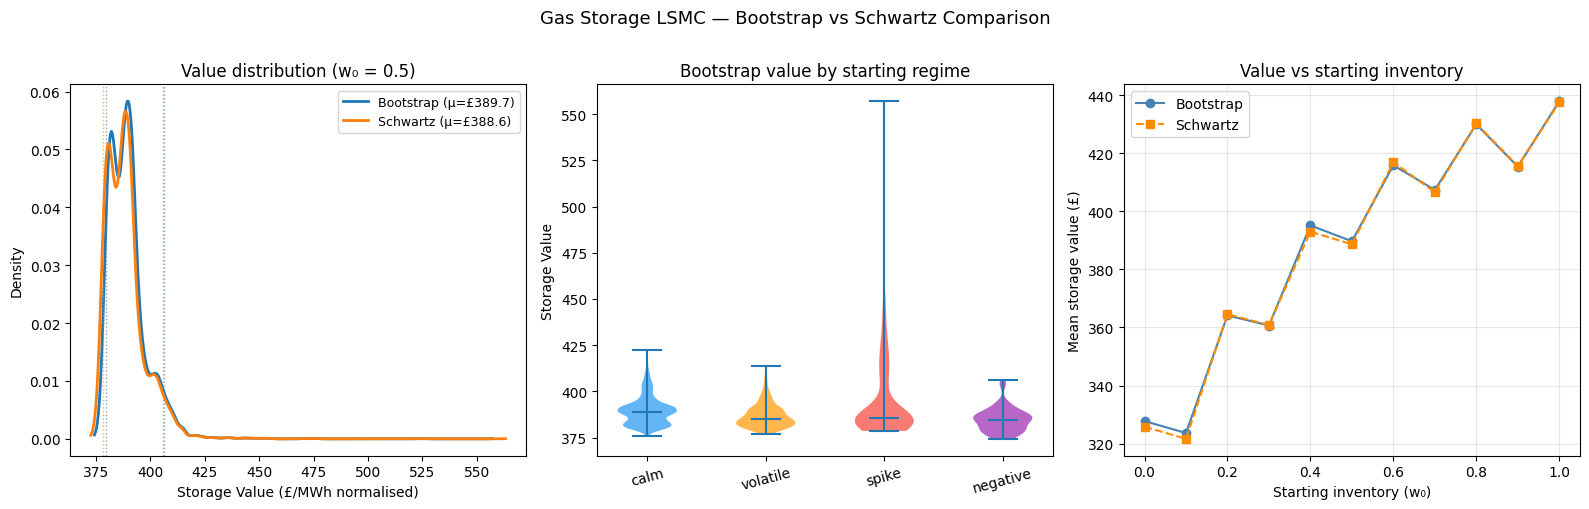

Saved: 07a_results_comparison.png

=== Summary (w₀ = 0.5) ===
Model                 Mean        Std   5th %ile  95th %ile
Bootstrap       £  389.69 £    9.13 £  379.60 £  406.23
Schwartz        £  388.63 £    9.37 £  378.19 £  405.59


In [66]:
# Cell 12 — Results comparison: storage value distribution by regime
#
# Focus on w_init = 0.5 (half-full) as the canonical starting inventory.
# Compare:
#   (a) Bootstrap vs Schwartz — value distribution (violin/kde)
#   (b) Value by starting regime (bootstrap paths only)
#   (c) Value as function of starting inventory (both models)

W_HALF_IDX = W_GRID // 2  # index 5 = w=0.5

boot_vals = V0_boot_paths[:, W_HALF_IDX]       # (N_PATHS,)
sw_vals   = V0_schwartz_paths[:, W_HALF_IDX]   # (N_PATHS,)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Panel A: KDE of value distribution ---
ax = axes[0]
for vals, label, colour in [
    (boot_vals, "Bootstrap", "steelblue"),
    (sw_vals,   "Schwartz",  "darkorange")
]:
    kde = stats.gaussian_kde(vals)
    x   = np.linspace(vals.min(), vals.max(), 400)
    ax.plot(x, kde(x), lw=2, label=f"{label} (μ=£{vals.mean():.1f})")
    ax.axvline(np.percentile(vals, 5),  lw=1, ls=":",  color=colour, alpha=0.7)
    ax.axvline(np.percentile(vals, 95), lw=1, ls=":",  color=colour, alpha=0.7)

ax.set_xlabel("Storage Value (£/MWh normalised)")
ax.set_ylabel("Density")
ax.set_title("Value distribution (w₀ = 0.5)")
ax.legend(fontsize=9)

# --- Panel B: Bootstrap values by starting regime ---
ax = axes[1]
regime_vals = {}
for r_idx, r in enumerate(REGIME_ORDER):
    mask = bootstrap_regimes[:, 0] == r_idx
    if mask.sum() > 10:
        regime_vals[r] = boot_vals[mask]

positions = list(range(len(regime_vals)))
labels_r = list(regime_vals.keys())
data_r   = [regime_vals[r] for r in labels_r]
bp = ax.violinplot(data_r, positions=positions, showmedians=True)
for i, patch in enumerate(bp["bodies"]):
    patch.set_facecolor(list(COLOURS.values())[i])
    patch.set_alpha(0.7)
ax.set_xticks(positions)
ax.set_xticklabels(labels_r, rotation=15)
ax.set_ylabel("Storage Value")
ax.set_title("Bootstrap value by starting regime")

# --- Panel C: Mean value vs starting inventory ---
ax = axes[2]
ax.plot(inventory_grid, V0_boot,     "o-", color="steelblue",  label="Bootstrap")
ax.plot(inventory_grid, V0_schwartz, "s--", color="darkorange", label="Schwartz")
ax.set_xlabel("Starting inventory (w₀)")
ax.set_ylabel("Mean storage value (£)")
ax.set_title("Value vs starting inventory")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("Gas Storage LSMC — Bootstrap vs Schwartz Comparison", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(DATA_DIR / "07a_results_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 07a_results_comparison.png")

# Summary table
print("\n=== Summary (w₀ = 0.5) ===")
print(f"{'Model':<15} {'Mean':>10} {'Std':>10} {'5th %ile':>10} {'95th %ile':>10}")
for label, vals in [("Bootstrap", boot_vals), ("Schwartz", sw_vals)]:
    print(f"{label:<15} £{vals.mean():>8.2f} £{vals.std():>8.2f} "
          f"£{np.percentile(vals,5):>8.2f} £{np.percentile(vals,95):>8.2f}")

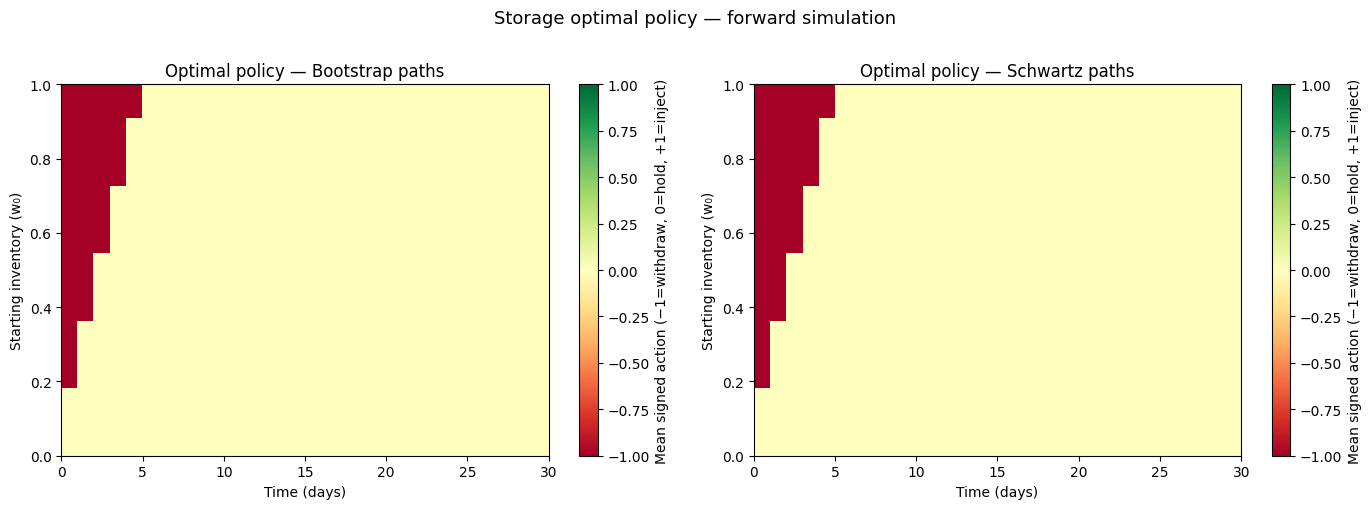

In [67]:
# Cell 13 — Policy heatmap from forward simulation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, policy_grid, title in [
    (axes[0], policy_boot_full,     "Bootstrap paths"),
    (axes[1], policy_schwartz_full, "Schwartz paths"),
]:
    im = ax.imshow(
        policy_grid.T,
        aspect="auto",
        origin="lower",
        cmap="RdYlGn",
        vmin=-1, vmax=1,
        extent=[0, T_DAYS, 0, 1]
    )
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Starting inventory (w₀)")
    ax.set_title(f"Optimal policy — {title}")
    plt.colorbar(im, ax=ax,
                 label="Mean signed action (−1=withdraw, 0=hold, +1=inject)")

plt.suptitle("Storage optimal policy — forward simulation", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(DATA_DIR / "07a_policy_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [68]:
# Cell 14 — Summary and save results

import json

# --- Save per-path storage values ---
# For each model and each starting inventory, save the per-path values
# as a long-form parquet: path_id, w_init, model, value

rows = []
for w_idx, w_val in enumerate(inventory_grid):
    for path_i in range(N_PATHS):
        rows.append({
            "path_id": path_i,
            "w_init":  round(w_val, 2),
            "model":   "bootstrap",
            "value":   float(V0_boot_paths[path_i, w_idx]),
            "starting_regime": REGIME_ORDER[bootstrap_regimes[path_i, 0]]
            if path_i < len(bootstrap_regimes) else None,
        })
        rows.append({
            "path_id": path_i,
            "w_init":  round(w_val, 2),
            "model":   "schwartz",
            "value":   float(V0_schwartz_paths[path_i, w_idx]),
            "starting_regime": None,
        })

results_df = pd.DataFrame(rows)
results_df.to_parquet(DATA_DIR / "gas_storage_results.parquet", index=False)
print(f"Saved: gas_storage_results_s2.parquet ({len(results_df):,} rows)")

# --- Save policy grid ---
# Store both bootstrap and schwartz policy grids in one .npy file
# Shape: (2, T_DAYS, W_GRID)  — axis 0: 0=bootstrap, 1=schwartz
policy_combined = np.stack([policy_boot_full, policy_schwartz_full], axis=0)
np.save(DATA_DIR / "gas_storage_policy.npy", policy_combined)
print(f"Saved: gas_storage_policy_s2.npy, shape {policy_combined.shape}")

# --- Save summary JSON ---
summary = {
    "schwartz_params": {
        "kappa": round(float(kappa_hat), 6),
        "mu":    round(float(mu_hat), 4),
        "sigma": round(float(sigma_hat), 4),
        "half_life_days": round(float(np.log(2) / kappa_hat), 2),
    },
    "storage_params": {
        "W_MAX": W_MAX, "W_MIN": W_MIN,
        "U_INJ": U_INJ, "U_WDR": U_WDR,
        "COST_INJ": COST_INJ, "COST_WDR": COST_WDR,
        "T_DAYS": T_DAYS, "N_PATHS": N_PATHS,
    },
    "segment_pool_sizes": pool_sizes,
    "results_w0_5": {
        "bootstrap": {
            "mean":  round(float(boot_vals.mean()), 4),
            "std":   round(float(boot_vals.std()), 4),
            "p5":    round(float(np.percentile(boot_vals, 5)), 4),
            "p95":   round(float(np.percentile(boot_vals, 95)), 4),
        },
        "schwartz": {
            "mean":  round(float(sw_vals.mean()), 4),
            "std":   round(float(sw_vals.std()), 4),
            "p5":    round(float(np.percentile(sw_vals, 5)), 4),
            "p95":   round(float(np.percentile(sw_vals, 95)), 4),
        },
    }
}

with open(DATA_DIR / "gas_storage_summary_s2.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Saved: gas_storage_summary.json")

# --- Print final narrative summary ---
print()
print("=" * 60)
print("NOTEBOOK 07a COMPLETE")
print("=" * 60)
print()
print("Method: Regime-stratified bootstrap Monte Carlo (10,000 paths)")
print(f"Segment pool: {sum(pool_sizes.values()):,} 48-step real segments")
print()
print("Schwartz OU calibration:")
print(f"  kappa={kappa_hat:.4f}/day, mu=£{mu_hat:.2f}, sigma=£{sigma_hat:.2f}")
print(f"  half-life = {np.log(2)/kappa_hat:.1f} days")
print()
print("Storage value at w₀=0.5 (mean ± std [5th, 95th]):")
print(f"  Bootstrap: £{boot_vals.mean():.2f} ± £{boot_vals.std():.2f}"
      f"  [£{np.percentile(boot_vals,5):.2f}, £{np.percentile(boot_vals,95):.2f}]")
print(f"  Schwartz:  £{sw_vals.mean():.2f} ± £{sw_vals.std():.2f}"
      f"  [£{np.percentile(sw_vals,5):.2f}, £{np.percentile(sw_vals,95):.2f}]")
print()
print("Key insight: Bootstrap paths contain real spikes and negative prices")
print("that the Schwartz OU model undersamples — compare tail percentiles.")
print()
print("Outputs saved:")
print("  gas_storage_results_s2.parquet   — per-path values (bootstrap + Schwartz)")
print("  gas_storage_policy_s2.npy        — policy grid [2, T, W_GRID]")
print("  gas_storage_summary_s2.json      — calibration params + headline stats")

Saved: gas_storage_results_s2.parquet (220,000 rows)
Saved: gas_storage_policy_s2.npy, shape (2, 30, 11)
Saved: gas_storage_summary.json

NOTEBOOK 07a COMPLETE

Method: Regime-stratified bootstrap Monte Carlo (10,000 paths)
Segment pool: 6,571 48-step real segments

Schwartz OU calibration:
  kappa=0.1688/day, mu=£82.08, sigma=£37.65
  half-life = 4.1 days

Storage value at w₀=0.5 (mean ± std [5th, 95th]):
  Bootstrap: £389.69 ± £9.13  [£379.60, £406.23]
  Schwartz:  £388.63 ± £9.37  [£378.19, £405.59]

Key insight: Bootstrap paths contain real spikes and negative prices
that the Schwartz OU model undersamples — compare tail percentiles.

Outputs saved:
  gas_storage_results_s2.parquet   — per-path values (bootstrap + Schwartz)
  gas_storage_policy_s2.npy        — policy grid [2, T, W_GRID]
  gas_storage_summary_s2.json      — calibration params + headline stats
